In [6]:
import numpy as np
from matplotlib import pyplot as plt
from sklearn.datasets import make_blobs

In [7]:
#Data Generation
X, y = make_blobs(n_samples=1000, n_features=2, centers=6, random_state=20, cluster_std=1)
print(X.shape, y.shape)

# Normalise
def Normalise(X):
    mu = X.mean(axis=0)
    std = X.std(axis=0)
    return (X - mu) / std

X = Normalise(X)

(1000, 2) (1000,)


In [8]:
# K-Means Functions
def initialise_centroids(X, k):
    np.random.seed(42)
    random_idx = np.random.permutation(X.shape[0])
    centroids = X[random_idx[:k]]
    return centroids

def closest_centroid(X, centroids):
    distances = np.sqrt(((X - centroids[:, np.newaxis])**2).sum(axis=2))
    return np.argmin(distances, axis=0)

def move_centroids(X, labels, k):
    new_centroids = np.array([X[labels == i].mean(axis=0) for i in range(k)])
    return new_centroids

def kmeans(X, k, n_iter=100):
    centroids = initialise_centroids(X, k)
    for _ in range(n_iter):
        labels = closest_centroid(X, centroids)
        new_centroids = move_centroids(X, labels, k)
        if np.allclose(centroids, new_centroids):  # convergence check
            break
        centroids = new_centroids
    return centroids, labels

In [9]:
#Inertia (sum of squared distances)
def compute_inertia(X, centroids, labels):
    inertia = 0
    for i, centroid in enumerate(centroids):
        inertia += np.sum((X[labels == i] - centroid)**2)
    return inertia


In [10]:
#Elbow Method
inertias = []
K_range = range(1, 11)

for k in K_range:
    centroids, labels = kmeans(X, k)
    inertia = compute_inertia(X, centroids, labels)
    inertias.append(inertia)

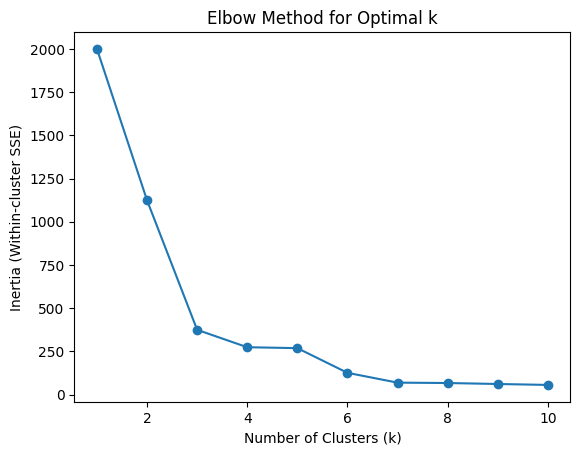

In [11]:
# Plot elbow graph
plt.plot(K_range, inertias, marker="o")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia (Within-cluster SSE)")
plt.title("Elbow Method for Optimal k")
plt.show()

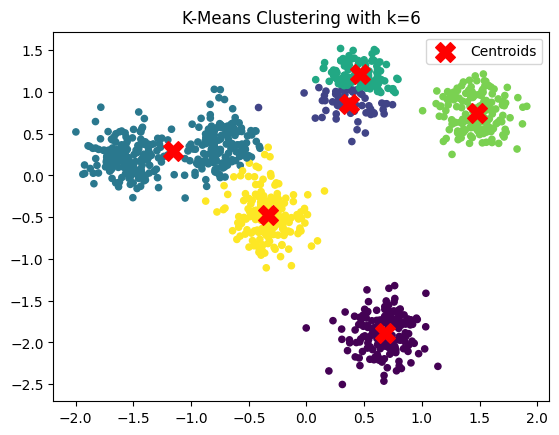

In [13]:
#Run with chosen k
best_k = 6
centroids, labels = kmeans(X, best_k)

plt.scatter(X[:,0], X[:,1], c=labels, cmap="viridis", s=20)
plt.scatter(centroids[:,0], centroids[:,1], c="red", marker="X", s=200, label="Centroids")
plt.title(f"K-Means Clustering with k={best_k}")
plt.legend()
plt.show()